In [2]:
import pandas as pd

df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data_2.csv")

df.shape
df.head()
df.info()
df.isnull().sum()
df['Is Fraudulent'].value_counts()
df['Is Fraudulent'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      23634 non-null  object 
 1   Customer ID         23634 non-null  object 
 2   Transaction Amount  23634 non-null  float64
 3   Transaction Date    23634 non-null  object 
 4   Payment Method      23634 non-null  object 
 5   Product Category    23634 non-null  object 
 6   Quantity            23634 non-null  int64  
 7   Customer Age        23634 non-null  int64  
 8   Customer Location   23634 non-null  object 
 9   Device Used         23634 non-null  object 
 10  IP Address          23634 non-null  object 
 11  Shipping Address    23634 non-null  object 
 12  Billing Address     23634 non-null  object 
 13  Is Fraudulent       23634 non-null  int64  
 14  Account Age Days    23634 non-null  int64  
 15  Transaction Hour    23634 non-null  int64  
dtypes: f

Is Fraudulent
0    0.948295
1    0.051705
Name: proportion, dtype: float64

In [3]:
columns_to_drop = [
    'Transaction ID',
    'Customer ID',
    'IP Address',
    'Shipping Address',
    'Billing Address'
]

df = df.drop(columns=columns_to_drop)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction Amount  23634 non-null  float64
 1   Transaction Date    23634 non-null  object 
 2   Payment Method      23634 non-null  object 
 3   Product Category    23634 non-null  object 
 4   Quantity            23634 non-null  int64  
 5   Customer Age        23634 non-null  int64  
 6   Customer Location   23634 non-null  object 
 7   Device Used         23634 non-null  object 
 8   Is Fraudulent       23634 non-null  int64  
 9   Account Age Days    23634 non-null  int64  
 10  Transaction Hour    23634 non-null  int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 2.0+ MB


In [4]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [5]:
df['Transaction Day'] = df['Transaction Date'].dt.day
df['Transaction Month'] = df['Transaction Date'].dt.month
df['Transaction Weekday'] = df['Transaction Date'].dt.weekday

In [6]:
df = df.drop(columns=['Transaction Date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction Amount   23634 non-null  float64
 1   Payment Method       23634 non-null  object 
 2   Product Category     23634 non-null  object 
 3   Quantity             23634 non-null  int64  
 4   Customer Age         23634 non-null  int64  
 5   Customer Location    23634 non-null  object 
 6   Device Used          23634 non-null  object 
 7   Is Fraudulent        23634 non-null  int64  
 8   Account Age Days     23634 non-null  int64  
 9   Transaction Hour     23634 non-null  int64  
 10  Transaction Day      23634 non-null  int32  
 11  Transaction Month    23634 non-null  int32  
 12  Transaction Weekday  23634 non-null  int32  
dtypes: float64(1), int32(3), int64(5), object(4)
memory usage: 2.1+ MB


In [8]:
for col in ['Payment Method','Product Category','Customer Location','Device Used']:
    print(col)
    print(df[col].nunique())
    print(df[col].value_counts().head())
    print('---')

Payment Method
4
Payment Method
debit card       5952
credit card      5923
PayPal           5899
bank transfer    5860
Name: count, dtype: int64
---
Product Category
5
Product Category
home & garden      4786
electronics        4748
toys & games       4730
clothing           4699
health & beauty    4671
Name: count, dtype: int64
---
Customer Location
14868
Customer Location
North Michael       30
East Michael        24
West Christopher    21
East David          20
Lake Michael        20
Name: count, dtype: int64
---
Device Used
3
Device Used
desktop    7923
mobile     7881
tablet     7830
Name: count, dtype: int64
---


In [9]:
df.groupby('Payment Method')['Is Fraudulent'].mean().sort_values(ascending=False)

Payment Method
bank transfer    0.055631
PayPal           0.052551
credit card      0.050819
debit card       0.047883
Name: Is Fraudulent, dtype: float64

In [10]:
df.groupby('Device Used')['Is Fraudulent'].mean().sort_values(ascending=False)

Device Used
mobile     0.054435
desktop    0.051243
tablet     0.049425
Name: Is Fraudulent, dtype: float64

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar
df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data_2.csv")  # cambia el nombre si hace falta

# Inspección rápida
print(df.shape)
display(df.head())
print(df.info())
print(df.isnull().sum())
print(df['Is Fraudulent'].value_counts(normalize=True))

(23634, 16)


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,8ca9f102-02a4-4207-ab63-484e83a1bdf0,42.32,2024-03-24 23:42:43,PayPal,electronics,1,40,East Jameshaven,desktop,110.87.246.85,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,0,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,4d158416-caae-4b09-bd5b-15235deb9129,301.34,2024-01-22 00:53:31,credit card,electronics,3,35,Kingstad,tablet,14.73.104.153,"5230 Stephanie Forge\nCollinsbury, PR 81853","5230 Stephanie Forge\nCollinsbury, PR 81853",0,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,ccae47b8-75c7-4f5a-aa9e-957deced2137,340.32,2024-01-22 08:06:03,debit card,toys & games,5,29,North Ryan,desktop,67.58.94.93,"195 Cole Oval\nPort Larry, IA 58422","4772 David Stravenue Apt. 447\nVelasquezside, ...",0,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,b04960c0-aeee-4907-b1cd-4819016adcef,95.77,2024-01-16 20:34:53,credit card,electronics,5,45,Kaylaville,mobile,202.122.126.216,"7609 Cynthia Square\nWest Brenda, NV 23016","7609 Cynthia Square\nWest Brenda, NV 23016",0,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,de9d6351-b3a7-4bc7-9a55-8f013eb66928,77.45,2024-01-16 15:47:23,credit card,clothing,5,42,North Edwardborough,desktop,96.77.232.76,"2494 Robert Ramp Suite 313\nRobinsonport, AS 5...","2494 Robert Ramp Suite 313\nRobinsonport, AS 5...",0,116,15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      23634 non-null  object 
 1   Customer ID         23634 non-null  object 
 2   Transaction Amount  23634 non-null  float64
 3   Transaction Date    23634 non-null  object 
 4   Payment Method      23634 non-null  object 
 5   Product Category    23634 non-null  object 
 6   Quantity            23634 non-null  int64  
 7   Customer Age        23634 non-null  int64  
 8   Customer Location   23634 non-null  object 
 9   Device Used         23634 non-null  object 
 10  IP Address          23634 non-null  object 
 11  Shipping Address    23634 non-null  object 
 12  Billing Address     23634 non-null  object 
 13  Is Fraudulent       23634 non-null  int64  
 14  Account Age Days    23634 non-null  int64  
 15  Transaction Hour    23634 non-null  int64  
dtypes: f

In [14]:
# Copia para EDA y modelo (buena práctica)
df_eda = df.copy()
df_model = df.copy()

# Eliminar columnas no útiles para modelo
cols_drop_model = [
    'Transaction ID',
    'Customer ID',
    'IP Address',
    'Shipping Address',
    'Billing Address'
]
df_model = df_model.drop(columns=cols_drop_model)

In [15]:
# Convertir fecha
df_model['Transaction Date'] = pd.to_datetime(df_model['Transaction Date'], errors='coerce')

# Verificar si hubo problemas de conversión
print(df_model['Transaction Date'].isnull().sum())

# Extraer variables temporales
df_model['Transaction Month'] = df_model['Transaction Date'].dt.month
df_model['Transaction Weekday'] = df_model['Transaction Date'].dt.weekday  # 0=lunes, 6=domingo

# Opcional: día del mes (puede sumar o no)
df_model['Transaction Day'] = df_model['Transaction Date'].dt.day

# Eliminar fecha original
df_model = df_model.drop(columns=['Transaction Date'])

0


In [16]:
df_model = df_model.drop(columns=['Customer Location'])
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction Amount   23634 non-null  float64
 1   Payment Method       23634 non-null  object 
 2   Product Category     23634 non-null  object 
 3   Quantity             23634 non-null  int64  
 4   Customer Age         23634 non-null  int64  
 5   Device Used          23634 non-null  object 
 6   Is Fraudulent        23634 non-null  int64  
 7   Account Age Days     23634 non-null  int64  
 8   Transaction Hour     23634 non-null  int64  
 9   Transaction Month    23634 non-null  int32  
 10  Transaction Weekday  23634 non-null  int32  
 11  Transaction Day      23634 non-null  int32  
dtypes: float64(1), int32(3), int64(5), object(3)
memory usage: 1.9+ MB
None


In [17]:
df.groupby('Device Used')['Is Fraudulent'].mean().sort_values(ascending=False)

Device Used
mobile     0.054435
desktop    0.051243
tablet     0.049425
Name: Is Fraudulent, dtype: float64

In [18]:
df.groupby('Product Category')['Is Fraudulent'].mean().sort_values(ascending=False)

Product Category
clothing           0.055331
home & garden      0.053907
health & beauty    0.052237
toys & games       0.048837
electronics        0.048231
Name: Is Fraudulent, dtype: float64

In [19]:
df.groupby('Transaction Hour')['Is Fraudulent'].mean().sort_values(ascending=False)

Transaction Hour
5     0.126336
0     0.124319
1     0.112595
4     0.104030
3     0.099237
2     0.096432
21    0.036573
9     0.035106
13    0.034930
19    0.034449
11    0.032770
14    0.032293
16    0.030572
22    0.029883
6     0.029592
10    0.029319
15    0.028866
18    0.028602
7     0.027837
8     0.027532
23    0.027168
20    0.026853
17    0.026709
12    0.023454
Name: Is Fraudulent, dtype: float64

In [20]:
df.groupby('Is Fraudulent')['Account Age Days'].describe()

,count,mean,std,min,25%,50%,75%,max
Is Fraudulent,,,,,,,,
0,22412.0,182.232911,105.821757,1.0,90.0,182.0,274.00,365.0
1,1222.0,113.141571,114.644129,1.0,17.0,52.5,208.75,365.0


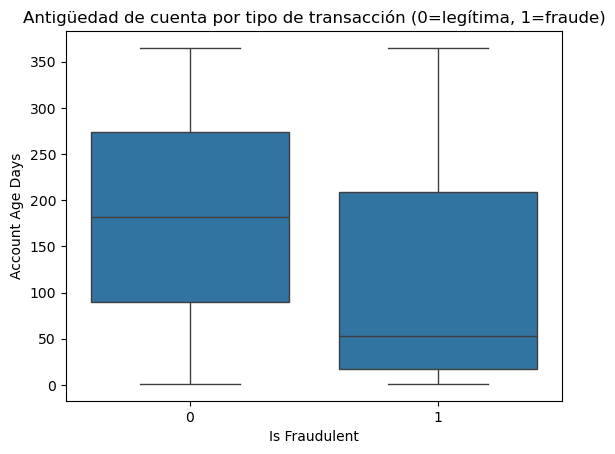

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Is Fraudulent', y='Account Age Days')
plt.title('Antigüedad de cuenta por tipo de transacción (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('Account Age Days')
plt.show()

In [22]:
df.groupby('Is Fraudulent')['Transaction Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Is Fraudulent,,,,,,,,
0,22412.0,211.226000,202.803353,10.00,67.885,148.205,287.0175,1980.94
1,1222.0,562.082561,817.306472,10.06,100.500,251.025,651.6450,9716.50


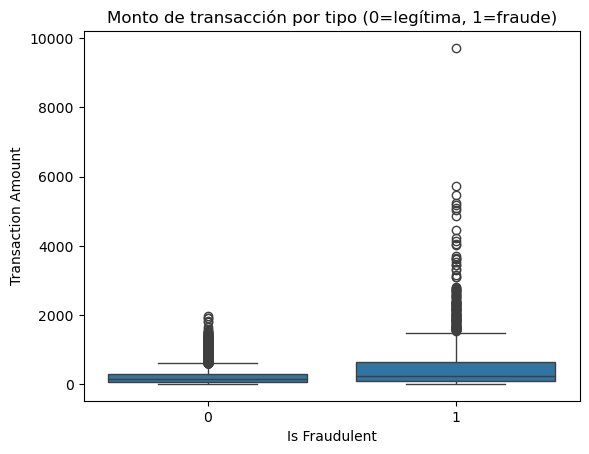

In [25]:
sns.boxplot(data=df, x='Is Fraudulent', y='Transaction Amount')
plt.title('Monto de transacción por tipo (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.show()

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

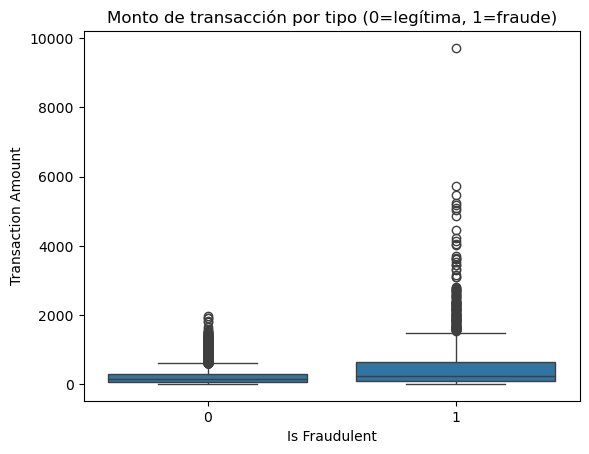

In [26]:
sns.boxplot(data=df, x='Is Fraudulent', y='Transaction Amount')
plt.title('Monto de transacción por tipo (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.show()

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data_2.csv")  # usa tu nombre real de archivo

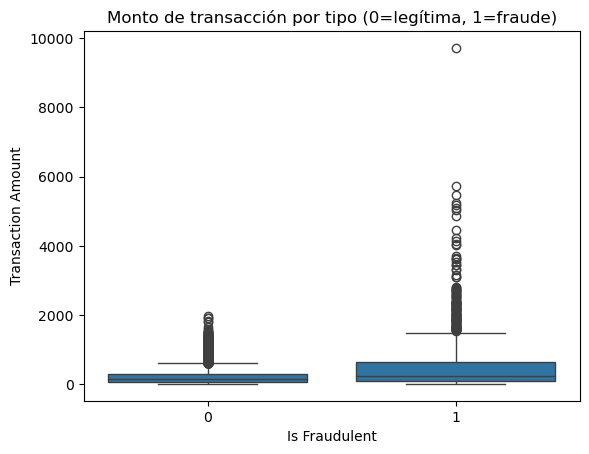

In [7]:
sns.boxplot(data=df, x='Is Fraudulent', y='Transaction Amount')
plt.title('Monto de transacción por tipo (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data_2.csv")  # cambia el nombre si hace falta
df_model = df.copy()

print(df_model.shape)
print(df_model.columns.tolist())

(23634, 16)
['Transaction ID', 'Customer ID', 'Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'IP Address', 'Shipping Address', 'Billing Address', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']


In [10]:
cols_drop = [
    'Transaction ID',
    'Customer ID',
    'IP Address',
    'Shipping Address',
    'Billing Address'
]

df_model = df_model.drop(columns=cols_drop)

print(df_model.shape)
print(df_model.columns.tolist())

(23634, 11)
['Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']


In [11]:
# Convertir a datetime
df_model['Transaction Date'] = pd.to_datetime(df_model['Transaction Date'], errors='coerce')

# Comprobar si hubo problemas de conversión
print("Nulos tras convertir fecha:", df_model['Transaction Date'].isnull().sum())

# Extraer variables temporales
df_model['Transaction Month'] = df_model['Transaction Date'].dt.month
df_model['Transaction Weekday'] = df_model['Transaction Date'].dt.weekday  # 0=Lunes, 6=Domingo
df_model['Transaction Day'] = df_model['Transaction Date'].dt.day

# Eliminar fecha original
df_model = df_model.drop(columns=['Transaction Date'])

print(df_model.dtypes)
print(df_model.shape)

Nulos tras convertir fecha: 0
Transaction Amount     float64
Payment Method          object
Product Category        object
Quantity                 int64
Customer Age             int64
Customer Location       object
Device Used             object
Is Fraudulent            int64
Account Age Days         int64
Transaction Hour         int64
Transaction Month        int32
Transaction Weekday      int32
Transaction Day          int32
dtype: object
(23634, 13)


In [12]:
df_model = df_model.drop(columns=['Customer Location'])

print(df_model.shape)
print(df_model.dtypes)

(23634, 12)
Transaction Amount     float64
Payment Method          object
Product Category        object
Quantity                 int64
Customer Age             int64
Device Used             object
Is Fraudulent            int64
Account Age Days         int64
Transaction Hour         int64
Transaction Month        int32
Transaction Weekday      int32
Transaction Day          int32
dtype: object


In [13]:
X = df_model.drop(columns=['Is Fraudulent'])
y = df_model['Is Fraudulent']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())
print("\nDistribución de y:")
print(y.value_counts(normalize=True))

Shape de X: (23634, 11)
Shape de y: (23634,)

Columnas de X:
['Transaction Amount', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Device Used', 'Account Age Days', 'Transaction Hour', 'Transaction Month', 'Transaction Weekday', 'Transaction Day']

Distribución de y:
Is Fraudulent
0    0.948295
1    0.051705
Name: proportion, dtype: float64


In [14]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape antes:", X.shape)
print("Shape después:", X_encoded.shape)

print("\nTipos de datos en X_encoded:")
print(X_encoded.dtypes.value_counts())

print("\nPrimeras columnas:")
print(X_encoded.columns.tolist()[:20])

Shape antes: (23634, 11)
Shape después: (23634, 17)

Tipos de datos en X_encoded:
bool       9
int64      4
int32      3
float64    1
Name: count, dtype: int64

Primeras columnas:
['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Transaction Hour', 'Transaction Month', 'Transaction Weekday', 'Transaction Day', 'Payment Method_bank transfer', 'Payment Method_credit card', 'Payment Method_debit card', 'Product Category_electronics', 'Product Category_health & beauty', 'Product Category_home & garden', 'Product Category_toys & games', 'Device Used_mobile', 'Device Used_tablet']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción fraude en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción fraude en y_test:")
print(y_test.value_counts(normalize=True))

X_train: (18907, 17)
X_test : (4727, 17)
y_train: (18907,)
y_test : (4727,)

Proporción fraude en y_train:
Is Fraudulent
0    0.948273
1    0.051727
Name: proportion, dtype: float64

Proporción fraude en y_test:
Is Fraudulent
0    0.948382
1    0.051618
Name: proportion, dtype: float64


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Modelo baseline con ajuste por desbalance
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Entrenamiento
log_model.fit(X_train, y_train)

# Predicción
y_pred_log = log_model.predict(X_test)

# Resultados
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification report:")
print(classification_report(y_test, y_pred_log, digits=4))

Matriz de confusión:
[[3268 1215]
 [  76  168]]

Classification report:
              precision    recall  f1-score   support

           0     0.9773    0.7290    0.8351      4483
           1     0.1215    0.6885    0.2065       244

    accuracy                         0.7269      4727
   macro avg     0.5494    0.7088    0.5208      4727
weighted avg     0.9331    0.7269    0.8026      4727



C:\Users\carlo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # aprende media/std en train
X_test_scaled = scaler.transform(X_test)         # aplica lo aprendido a test

# Modelo logistic regression (baseline mejorado)
log_model_scaled = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

log_model_scaled.fit(X_train_scaled, y_train)

y_pred_log_scaled = log_model_scaled.predict(X_test_scaled)

print("Matriz de confusión (LogReg escalada):")
print(confusion_matrix(y_test, y_pred_log_scaled))

print("\nClassification report (LogReg escalada):")
print(classification_report(y_test, y_pred_log_scaled, digits=4))

Matriz de confusión (LogReg escalada):
[[3252 1231]
 [  78  166]]

Classification report (LogReg escalada):
              precision    recall  f1-score   support

           0     0.9766    0.7254    0.8325      4483
           1     0.1188    0.6803    0.2023       244

    accuracy                         0.7231      4727
   macro avg     0.5477    0.7029    0.5174      4727
weighted avg     0.9323    0.7231    0.7999      4727



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Matriz de confusión (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification report (Random Forest):")
print(classification_report(y_test, y_pred_rf, digits=4))

Matriz de confusión (Random Forest):
[[4480    3]
 [ 222   22]]

Classification report (Random Forest):
              precision    recall  f1-score   support

           0     0.9528    0.9993    0.9755      4483
           1     0.8800    0.0902    0.1636       244

    accuracy                         0.9524      4727
   macro avg     0.9164    0.5447    0.5695      4727
weighted avg     0.9490    0.9524    0.9336      4727



In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Probabilidades de clase 1 (fraude)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Umbral alternativo (prueba)
threshold = 0.20
y_pred_rf_tuned = (y_prob_rf >= threshold).astype(int)

print(f"Threshold usado: {threshold}")
print("Matriz de confusión (RF con threshold ajustado):")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification report (RF con threshold ajustado):")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))

Threshold usado: 0.2
Matriz de confusión (RF con threshold ajustado):
[[4342  141]
 [ 152   92]]

Classification report (RF con threshold ajustado):
              precision    recall  f1-score   support

           0     0.9662    0.9685    0.9674      4483
           1     0.3948    0.3770    0.3857       244

    accuracy                         0.9380      4727
   macro avg     0.6805    0.6728    0.6766      4727
weighted avg     0.9367    0.9380    0.9373      4727



In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Probabilidades ya calculadas del RF (si no existen, las recalculamos)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []
for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    results.append({
        'threshold': t,
        'precision_fraud': precision_score(y_test, y_pred_t, zero_division=0),
        'recall_fraud': recall_score(y_test, y_pred_t, zero_division=0),
        'f1_fraud': f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision_fraud,recall_fraud,f1_fraud
0,0.10,0.219156,0.553279,0.313953
1,0.15,0.304945,0.454918,0.365132
2,0.20,0.394850,0.377049,0.385744
3,0.25,0.464286,0.319672,0.378641
4,0.30,0.473282,0.254098,0.330667
5,0.40,0.603448,0.143443,0.231788
6,0.50,0.880000,0.090164,0.163569


In [21]:
# Predicción final RF con threshold elegido
threshold_final = 0.25
y_pred_rf_final = (y_prob_rf >= threshold_final).astype(int)

print(f"Threshold final elegido: {threshold_final}")
print("Matriz de confusión (RF final):")
print(confusion_matrix(y_test, y_pred_rf_final))

print("\nClassification report (RF final):")
print(classification_report(y_test, y_pred_rf_final, digits=4))

Threshold final elegido: 0.25
Matriz de confusión (RF final):
[[4393   90]
 [ 166   78]]

Classification report (RF final):
              precision    recall  f1-score   support

           0     0.9636    0.9799    0.9717      4483
           1     0.4643    0.3197    0.3786       244

    accuracy                         0.9458      4727
   macro avg     0.7139    0.6498    0.6752      4727
weighted avg     0.9378    0.9458    0.9411      4727



In [22]:
comparison = pd.DataFrame([
    {
        'Modelo': 'Logistic Regression (balanced)',
        'Threshold': 0.50,
        'Precision_fraude': 0.1188,
        'Recall_fraude': 0.6803,
        'F1_fraude': 0.2023
    },
    {
        'Modelo': 'Random Forest (default)',
        'Threshold': 0.50,
        'Precision_fraude': 0.8800,
        'Recall_fraude': 0.0902,
        'F1_fraude': 0.1636
    },
    {
        'Modelo': 'Random Forest (ajustado)',
        'Threshold': 0.25,
        'Precision_fraude': 0.4643,
        'Recall_fraude': 0.3197,
        'F1_fraude': 0.3786
    }
])

comparison

,Modelo,Threshold,Precision_fraude,Recall_fraude,F1_fraude
0,Logistic Regression (balanced),0.50,0.1188,0.6803,0.2023
1,Random Forest (default),0.50,0.8800,0.0902,0.1636
2,Random Forest (ajustado),0.25,0.4643,0.3197,0.3786


In [14]:
print("Duplicados exactos:", df.duplicated().sum())

print("Horas fuera de 0-23:", (~df['Transaction Hour'].between(0,23)).sum())
print("Edad fuera de 0-120:", (~df['Customer Age'].between(0,120)).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Amount <= 0:", (df['Transaction Amount'] <= 0).sum())
print("Account Age Days < 0:", (df['Account Age Days'] < 0).sum())

Duplicados exactos: 0
Horas fuera de 0-23: 0
Edad fuera de 0-120: 0
Quantity <= 0: 0
Amount <= 0: 0
Account Age Days < 0: 0


In [4]:
import pandas as pd
df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data_2.csv")  # pon el nombre real de tu archivo
print(df.shape)

(23634, 16)


In [5]:
print("Duplicados exactos:", df.duplicated().sum())

print("Horas fuera de 0-23:", (~df['Transaction Hour'].between(0,23)).sum())
print("Edad fuera de 0-120:", (~df['Customer Age'].between(0,120)).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Amount <= 0:", (df['Transaction Amount'] <= 0).sum())
print("Account Age Days < 0:", (df['Account Age Days'] < 0).sum())

Duplicados exactos: 0
Horas fuera de 0-23: 0
Edad fuera de 0-120: 1
Quantity <= 0: 0
Amount <= 0: 0
Account Age Days < 0: 0


In [6]:
df[df['Customer Age'].between(0,120) == False][['Customer Age']]

,Customer Age
12919,-2


In [7]:
df = df[df['Customer Age'].between(0,120)]
print(df.shape)

(23633, 16)


In [8]:
print("Edad fuera de 0-120:", (~df['Customer Age'].between(0,120)).sum())

Edad fuera de 0-120: 0


In [9]:
import pandas as pd

# Partimos de df ya limpio
df_model = df.copy()

# 1) Eliminar columnas no útiles para modelado
cols_drop = [
    'Transaction ID', 'Customer ID', 'IP Address',
    'Shipping Address', 'Billing Address'
]
df_model = df_model.drop(columns=cols_drop)

# 2) Convertir fecha y extraer variables temporales
df_model['Transaction Date'] = pd.to_datetime(df_model['Transaction Date'], errors='coerce')
df_model['Transaction Month'] = df_model['Transaction Date'].dt.month
df_model['Transaction Weekday'] = df_model['Transaction Date'].dt.weekday
df_model['Transaction Day'] = df_model['Transaction Date'].dt.day
df_model = df_model.drop(columns=['Transaction Date'])

# 3) Excluir Customer Location del modelo
df_model = df_model.drop(columns=['Customer Location'])

# 4) Separar X e y
X = df_model.drop(columns=['Is Fraudulent'])
y = df_model['Is Fraudulent']

# 5) One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("df_model shape:", df_model.shape)
print("X_encoded shape:", X_encoded.shape)
print("Fraude rate:", y.mean())

df_model shape: (23633, 12)
X_encoded shape: (23633, 17)
Fraude rate: 0.0517073583548428


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Fraude en train:", y_train.mean())
print("Fraude en test :", y_test.mean())

Fraude en train: 0.05172960964773088
Fraude en test : 0.051618362597842186


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

threshold_final = 0.25
y_pred_rf_final = (y_prob_rf >= threshold_final).astype(int)

print("Threshold final:", threshold_final)
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_final))

print("\nReporte:")
print(classification_report(y_test, y_pred_rf_final, digits=4))

Threshold final: 0.25
Matriz de confusión:
[[4370  113]
 [ 163   81]]

Reporte:
              precision    recall  f1-score   support

           0     0.9640    0.9748    0.9694      4483
           1     0.4175    0.3320    0.3699       244

    accuracy                         0.9416      4727
   macro avg     0.6908    0.6534    0.6696      4727
weighted avg     0.9358    0.9416    0.9384      4727



In [13]:
df.to_csv("Fraudulent_E-Commerce_Transaction_Data_2_clean.csv", index=False)

In [21]:
import os

output_path = os.path.join(os.getcwd(), "Fraudulent_E-Commerce_Transaction_Data_2_clean.csv")
df.to_csv(output_path, index=False, encoding="utf-8")

print("Guardado en:", output_path)

Guardado en: C:\Users\carlo\ANACONDA\Fraudulent_E-Commerce_Transaction_Data_2_clean.csv


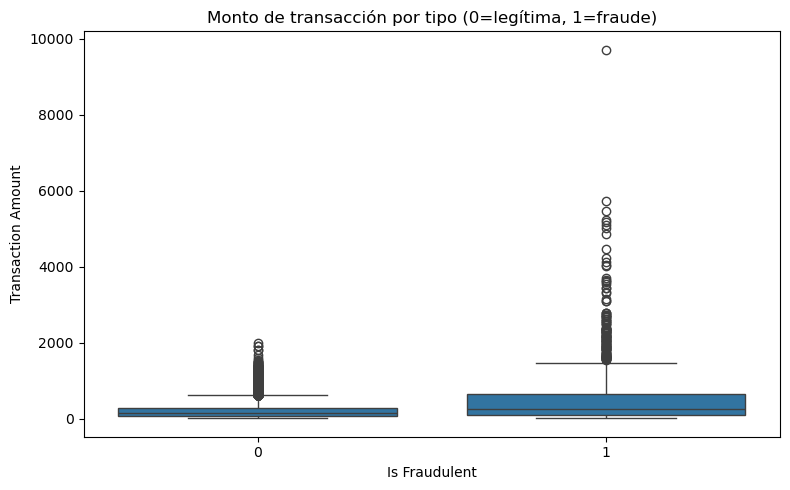

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Is Fraudulent', y='Transaction Amount')
plt.title('Monto de transacción por tipo (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.savefig("boxplot_transaction_amount.png", dpi=200)
plt.show()

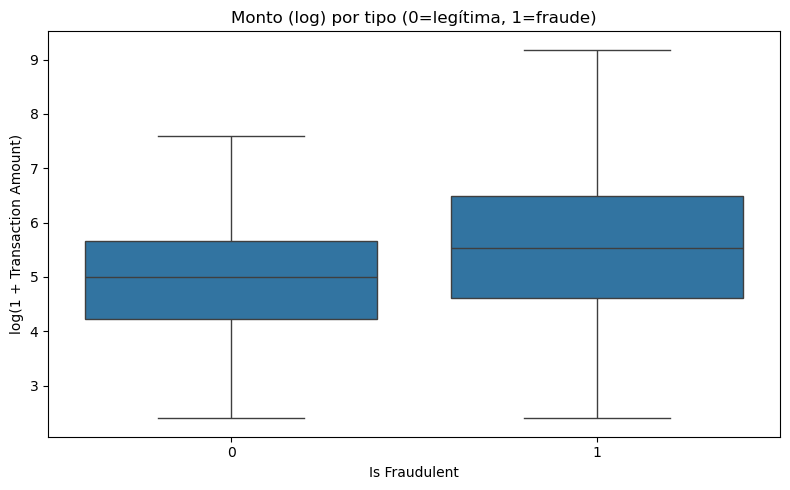

In [23]:
import numpy as np

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Is Fraudulent', y=np.log1p(df['Transaction Amount']))
plt.title('Monto (log) por tipo (0=legítima, 1=fraude)')
plt.xlabel('Is Fraudulent')
plt.ylabel('log(1 + Transaction Amount)')
plt.tight_layout()
plt.savefig("boxplot_transaction_amount_log.png", dpi=200)
plt.show()

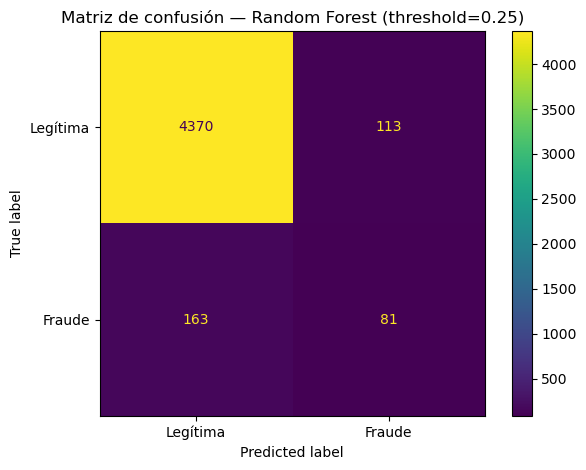

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_final, display_labels=["Legítima","Fraude"])
plt.title("Matriz de confusión — Random Forest (threshold=0.25)")
plt.tight_layout()
plt.savefig("confusion_matrix_rf_025.png", dpi=200)
plt.show()